### Preparación y Descarga de Datos

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# Descarga de datos (5 años a partir de hoy)
tickers = ["IBM", "WMT"]
data = yf.download(tickers, period="5y")['Close']

[*********************100%***********************]  2 of 2 completed


In [11]:
data

Ticker,IBM,WMT,IBM_MA20
Date,,,
2021-01-21,102.328514,45.111298,NaN
2021-01-22,92.192825,45.572239,NaN
2021-01-25,92.169510,45.531746,NaN
2021-01-26,95.208649,45.939720,NaN
2021-01-27,95.193115,44.796757,NaN
...,...,...,...
2026-01-13,303.160004,120.360001,302.238000
2026-01-14,309.029999,120.040001,302.256500
2026-01-15,297.950012,119.199997,301.995001


In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1255 entries, 2021-01-21 to 2026-01-20
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   IBM       1255 non-null   float64
 1   WMT       1255 non-null   float64
 2   IBM_MA20  1236 non-null   float64
dtypes: float64(3)
memory usage: 39.2 KB


### Coeficiente de Correlación de Pearson

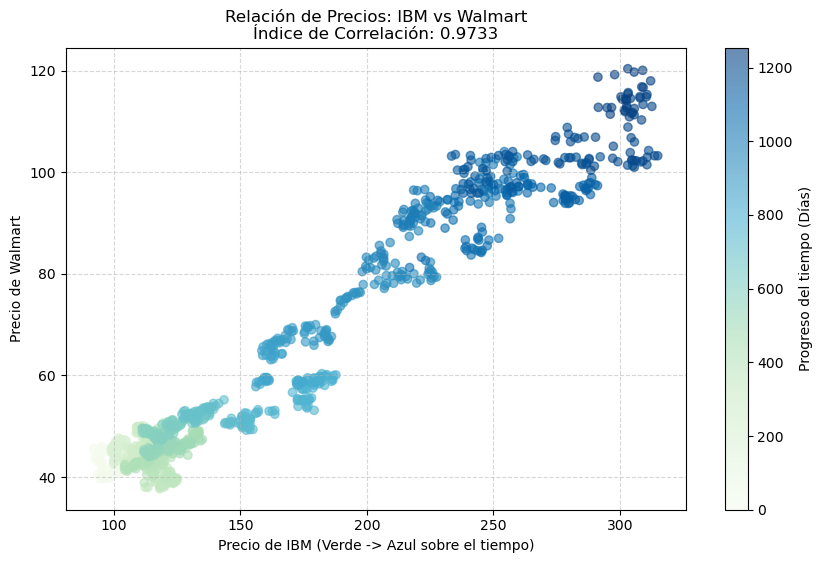

In [28]:
import matplotlib.pyplot as plt

# Calcular la correlación nuevamente
correlation = data['IBM'].corr(data['WMT'])

plt.figure(figsize=(10, 6))
# Usamos un colormap 'GnBu' (Green to Blue) para representar el paso del tiempo
scatter = plt.scatter(data['IBM'], data['WMT'], c=range(len(data)), cmap='GnBu', alpha=0.6)

plt.title(f'Relación de Precios: IBM vs Walmart\nÍndice de Correlación: {correlation:.4f}')
plt.xlabel('Precio de IBM (Verde -> Azul sobre el tiempo)')
plt.ylabel('Precio de Walmart')
plt.colorbar(scatter, label='Progreso del tiempo (Días)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### ¿Existe alguna correlación entre los precios de las acciones de ambas empresas?

El coeficiente de correlación de Pearson de 0.9733 indica una correlación positiva muy fuerte. Esto significa que los precios de IBM y Walmart se mueven en la misma dirección la mayor parte del tiempo: cuando el precio de IBM sube, es muy probable que el de Walmart también lo haga, y viceversa.

Y como se puede observar en la gráfica los puntos no están dispersos al azar, sino que forman una línea diagonal ascendente muy clara.

Cuanto más delgada y definida sea esa "línea" de puntos, más se acerca el índice a 1. En tu caso, al ser 0.97, verás una línea casi recta.

### Descomposición 
#### Tendencia, Estacionalidad y Residuo

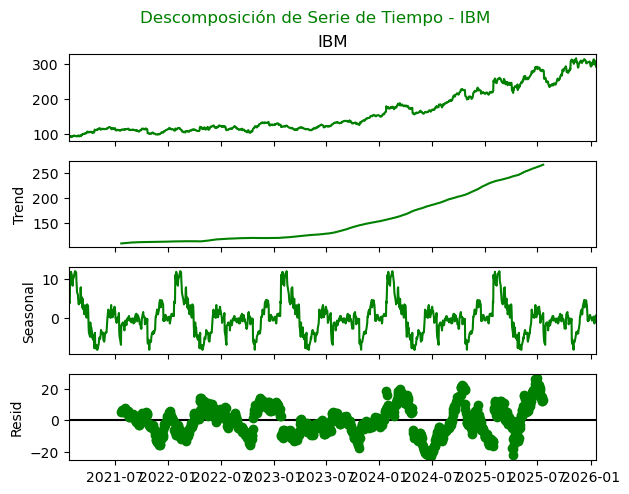

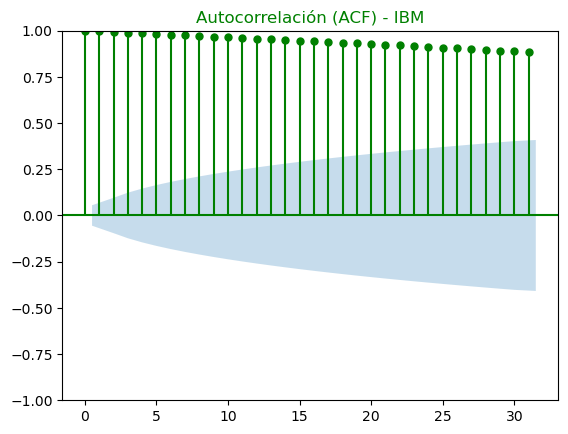

In [65]:
# --- ANÁLISIS PARA IBM (VERDE) ---

# 1. Gráfico de Descomposición - IBM
result_ibm = seasonal_decompose(data['IBM'], model='additive', period=252)
fig_ibm = result_ibm.plot()
for ax in fig_ibm.get_axes():
    ax.get_lines()[0].set_color('green')
plt.suptitle('Descomposición de Serie de Tiempo - IBM', y=1.02, color='green')
plt.show()

# 2. Correlograma (ACF) - IBM (Corrección de vlines_kwargs)
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(data['IBM'], color='green', vlines_kwargs={'colors': 'green'})
plt.title("Autocorrelación (ACF) - IBM", color='green')
plt.show()

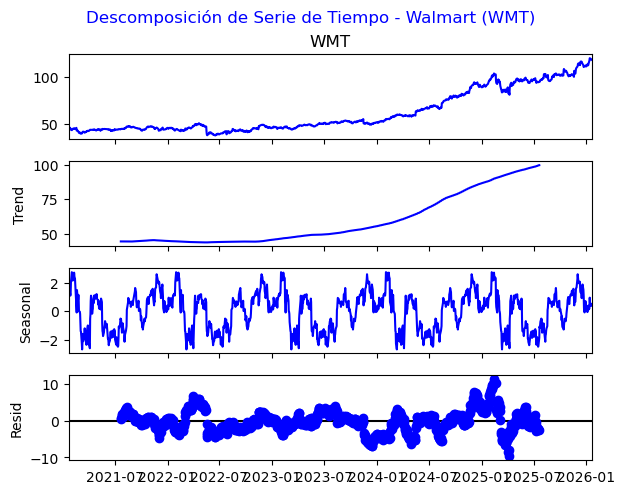

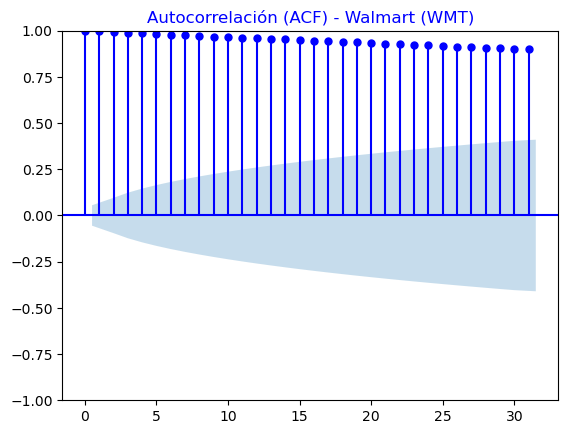

In [67]:
# --- ANÁLISIS PARA WALMART (AZUL) ---

# 1. Gráfico de Descomposición - WMT
result_wmt = seasonal_decompose(data['WMT'], model='additive', period=252)
fig_wmt = result_wmt.plot()
for ax in fig_wmt.get_axes():
    ax.get_lines()[0].set_color('blue')
plt.suptitle('Descomposición de Serie de Tiempo - Walmart (WMT)', y=1.02, color='blue')
plt.show()

# 2. Correlograma (ACF) - WMT (Corrección de vlines_kwargs)
plot_acf(data['WMT'], color='blue', vlines_kwargs={'colors': 'blue'})
plt.title("Autocorrelación (ACF) - Walmart (WMT)", color='blue')
plt.show()

### Interpretación

En la descomposición, ambas series muestran una tendencia alcista clara y una estacionalidad repetitiva, lo que sugiere patrones anuales constantes. Los residuos muestran que IBM tiene una mayor variabilidad aleatoria comparada con Walmart. En cuanto a los correlogramas, la lenta caída de las autocorrelaciones (manteniéndose fuera del intervalo de confianza) es una evidencia visual de la no-estacionariedad, confirmando que el precio pasado tiene un peso significativo en el precio actual.

### Prueba de Dickey-Fuller

In [7]:
def check_stationarity(series, name):
    result = adfuller(series)
    print(f"--- Prueba para {name} ---")
    print(f"P-value: {result[1]:.4f}")
    if result[1] <= 0.05:
        print("Es estacionaria")
    else:
        print("No es estacionaria")

check_stationarity(data['IBM'], "IBM")
check_stationarity(data['WMT'], "Walmart")

--- Prueba para IBM ---
P-value: 0.9620
No es estacionaria
--- Prueba para Walmart ---
P-value: 0.9986
No es estacionaria


### Interpretación de la Prueba de Dickey-Fuller

En ambas series, el p-value es significativamente mayor al umbral de 0.05. Por lo tanto, no hay evidencia suficiente para rechazar la hipótesis nula ($H_0$), lo que confirma que ambas series no son estacionarias. Esto significa que los precios de IBM y Walmart tienen una tendencia (dependen del tiempo) y su media no es constante, lo cual es característico de los activos financieros.

### Promedios Móviles

--- PRONÓSTICOS PARA EL SIGUIENTE DÍA ---
Pronóstico IBM (basado en MA20): $301.66
Pronóstico Walmart (basado en MA20): $114.66


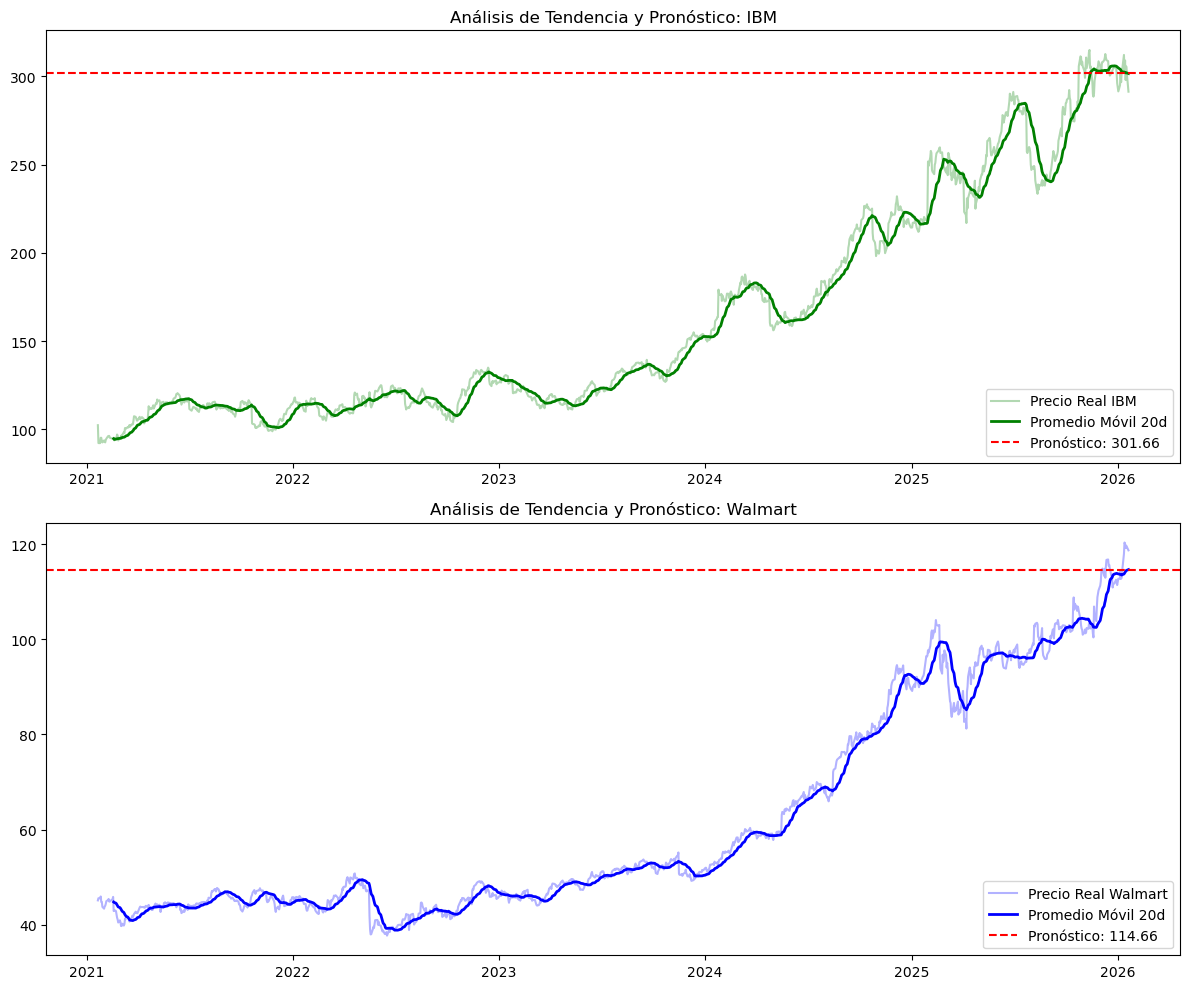

In [30]:
# 1. Cálculos de Promedios Móviles
data['IBM_MA20'] = data['IBM'].rolling(window=20).mean()
data['WMT_MA20'] = data['WMT'].rolling(window=20).mean()

# 2. Obtención de pronósticos (último valor calculado)
forecast_ibm = data['IBM_MA20'].iloc[-1]
forecast_wmt = data['WMT_MA20'].iloc[-1]

print(f"--- PRONÓSTICOS PARA EL SIGUIENTE DÍA ---")
print(f"Pronóstico IBM (basado en MA20): ${forecast_ibm:.2f}")
print(f"Pronóstico Walmart (basado en MA20): ${forecast_wmt:.2f}")

# 3. Gráfico Comparativo
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Subplot IBM
ax1.plot(data['IBM'], color='green', alpha=0.3, label='Precio Real IBM')
ax1.plot(data['IBM_MA20'], color='green', linewidth=2, label='Promedio Móvil 20d')
ax1.axhline(forecast_ibm, color='red', linestyle='--', label=f'Pronóstico: {forecast_ibm:.2f}')
ax1.set_title('Análisis de Tendencia y Pronóstico: IBM')
ax1.legend()

# Subplot Walmart
ax2.plot(data['WMT'], color='blue', alpha=0.3, label='Precio Real Walmart')
ax2.plot(data['WMT_MA20'], color='blue', linewidth=2, label='Promedio Móvil 20d')
ax2.axhline(forecast_wmt, color='red', linestyle='--', label=f'Pronóstico: {forecast_wmt:.2f}')
ax2.set_title('Análisis de Tendencia y Pronóstico: Walmart')
ax2.legend()

plt.tight_layout()
plt.show()

### Análisis Gráfico de Promedios Móviles

El pronóstico mediante promedios móviles es útil para entender la dirección de la tendencia a largo plazo, pero como herramienta de predicción diaria es limitada, ya que ignora la volatilidad inmediata y reacciona con retraso a los movimientos del mercado.

##### No son pronósticos precisos para el día a día:

El método de promedios móviles tiene un retraso intrínseco (lag). Como usa datos de los últimos 20 días, si el precio cambia bruscamente hoy por una noticia, el promedio no lo reflejará de inmediato.

##### Utilidad real: 
Son excelentes para identificar la inercia o dirección del mercado. Si el precio está por encima del promedio móvil, la tendencia es alcista, pero no sirve para predecir el precio exacto de cierre de mañana con alta confianza en mercados tan volátiles.

### Pronóstico con Rango de Error Basado en Volatilidad

Este rango se construye usando 2 desviaciones estándar (lo que en estadística se asocia a un nivel de confianza del 95% en una distribución normal).

A pesar de tener un rango, este sigue basándose en datos históricos (los últimos 20 días). Si mañana el mercado recibe una noticia inesperada (un shock externo), el precio podría romper estos límites. Por lo tanto, el pronóstico es una buena referencia de tendencia, pero no una garantía de precio exacto.

--- ANÁLISIS DE RANGO PARA WALMART ---
Punto central (Pronóstico MA20): $114.66
Rango esperado para mañana: Entre $108.05 y $121.27


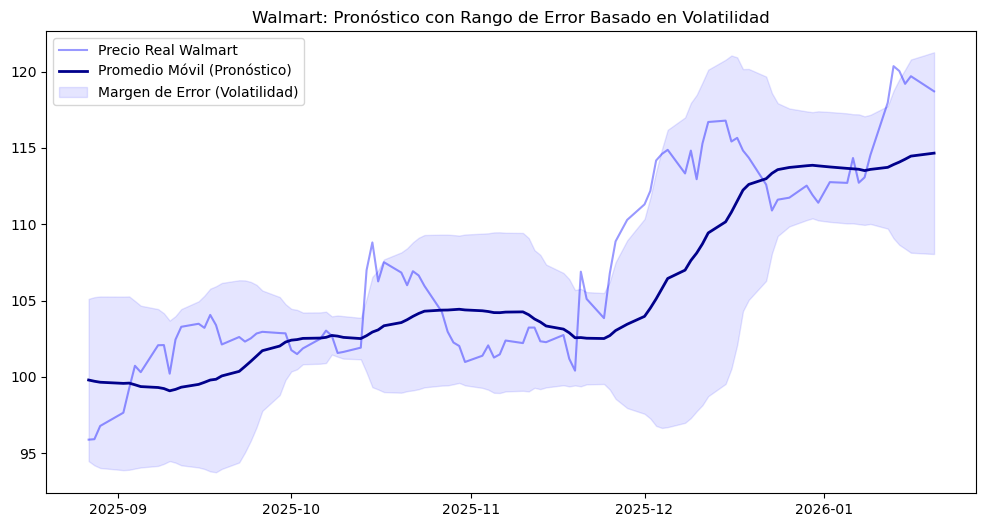

In [38]:
import numpy as np

# 1. Calculamos la Desviación Estándar de los últimos 20 días
data['WMT_Std20'] = data['WMT'].rolling(window=20).std()

# 2. Definimos el margen de error (Usamos 2 desviaciones estándar para un ~95% de confianza)
ultimo_promedio = data['WMT_MA20'].iloc[-1]
ultima_desviacion = data['WMT_Std20'].iloc[-1]

margen_superior = ultimo_promedio + (2 * ultima_desviacion)
margen_inferior = ultimo_promedio - (2 * ultima_desviacion)

print(f"--- ANÁLISIS DE RANGO PARA WALMART ---")
print(f"Punto central (Pronóstico MA20): ${ultimo_promedio:.2f}")
print(f"Rango esperado para mañana: Entre ${margen_inferior:.2f} y ${margen_superior:.2f}")

# 3. Gráfico con área de error (Sombreado)
plt.figure(figsize=(12, 6))
plt.plot(data['WMT'].tail(100), label='Precio Real Walmart', color='blue', alpha=0.4)
plt.plot(data['WMT_MA20'].tail(100), label='Promedio Móvil (Pronóstico)', color='darkblue', linewidth=2)

# Sombreado del margen de error
plt.fill_between(data.index[-100:], 
                 (data['WMT_MA20'] - 2*data['WMT_Std20']).tail(100), 
                 (data['WMT_MA20'] + 2*data['WMT_Std20']).tail(100), 
                 color='blue', alpha=0.1, label='Margen de Error (Volatilidad)')

plt.title('Walmart: Pronóstico con Rango de Error Basado en Volatilidad')
plt.legend()
plt.show()

Para Walmart, aunque el promedio móvil sugiere 114.66, el análisis de volatilidad nos indica que existe un margen de fluctuación de aproximadamente 6.61. Esto significa que, estadísticamente, el precio de cierre de mañana tiene una alta probabilidad de caer entre 108.05 y 121.27.

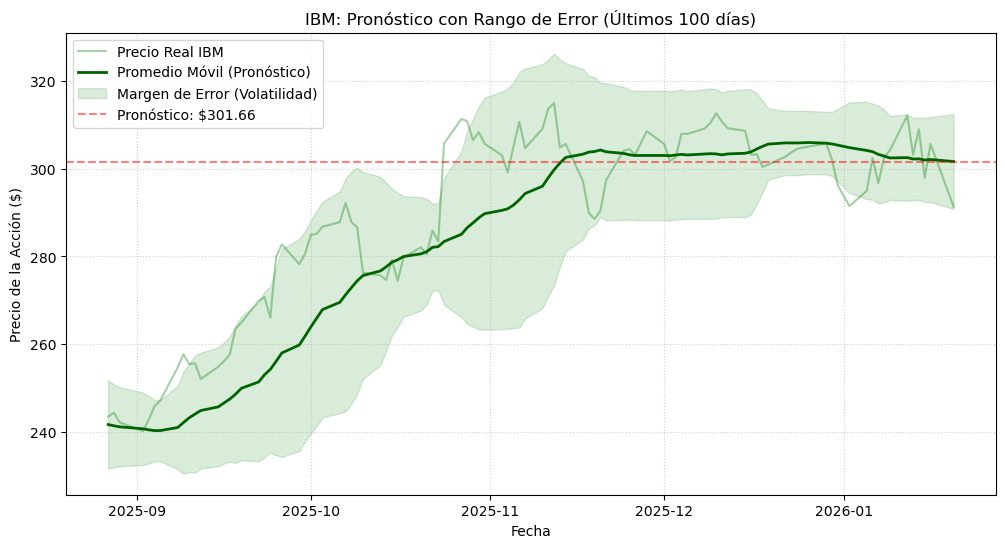


--- ANÁLISIS DE RANGO PARA IBM ---
Punto central (Pronóstico MA20): $301.66
Rango esperado para mañana: Entre $296.24 y $307.07


In [76]:
import matplotlib.pyplot as plt

# 1. Aseguramos que tenemos los cálculos (por si acaso no has corrido la celda anterior)
data['IBM_Std20'] = data['IBM'].rolling(window=20).std()

# 2. Configuración del gráfico
plt.figure(figsize=(12, 6))

# Graficamos los últimos 100 días para que se vea con detalle el final de la serie
# 'tail(100)' nos permite hacer zoom en los datos más recientes
plt.plot(data['IBM'].tail(100), label='Precio Real IBM', color='forestgreen', alpha=0.4)
plt.plot(data['IBM_MA20'].tail(100), label='Promedio Móvil (Pronóstico)', color='darkgreen', linewidth=2)

# 3. Sombreado del área de error (Intervalo de confianza del 95%)
# Usamos 2 desviaciones estándar sobre el promedio móvil
plt.fill_between(data.index[-100:], 
                 (data['IBM_MA20'] - 2*data['IBM_Std20']).tail(100), 
                 (data['IBM_MA20'] + 2*data['IBM_Std20']).tail(100), 
                 color='green', alpha=0.15, label='Margen de Error (Volatilidad)')

# Marcamos el punto de pronóstico final
plt.axhline(u_prom_ibm, color='red', linestyle='--', alpha=0.5, label=f'Pronóstico: ${u_prom_ibm:.2f}')

plt.title('IBM: Pronóstico con Rango de Error (Últimos 100 días)')
plt.xlabel('Fecha')
plt.ylabel('Precio de la Acción ($)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# --- CÁLCULO PARA IBM ---
data['MA20_IBM'] = data['IBM'].rolling(window=20).mean()
ultimo_promedio_ibm = data['MA20_IBM'].iloc[-1]
std_ibm = data['IBM'].rolling(window=20).std().iloc[-1]
margen_inferior_ibm = ultimo_promedio_ibm - std_ibm
margen_superior_ibm = ultimo_promedio_ibm + std_ibm

print(f"\n--- ANÁLISIS DE RANGO PARA IBM ---")
print(f"Punto central (Pronóstico MA20): ${ultimo_promedio_ibm:.2f}")
print(f"Rango esperado para mañana: Entre ${margen_inferior_ibm:.2f} y ${margen_superior_ibm:.2f}")

RESUMEN DE PRONÓSTICOS PARA EL SIGUIENTE DÍA:
Empresa  Pronóstico (MA20)  Límite Inferior  Límite Superior
    IBM             301.66           290.83           312.49
Walmart             114.66           108.05           121.27


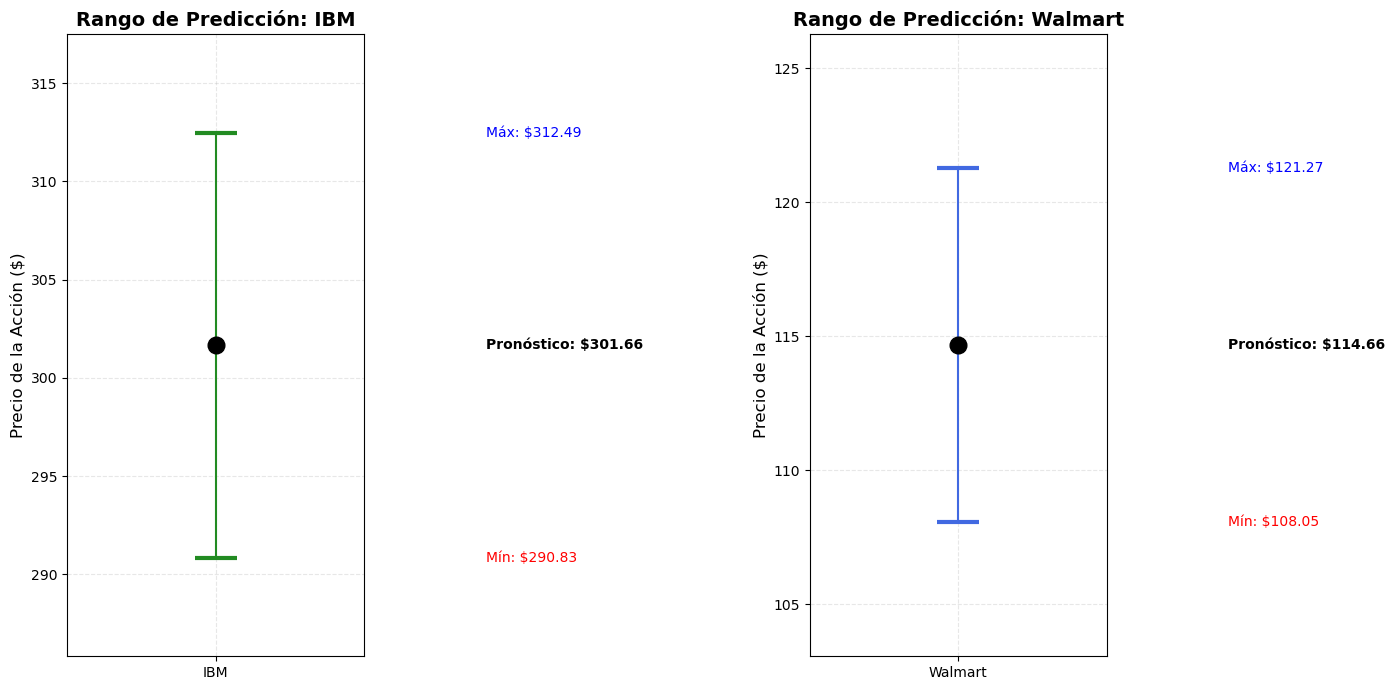

In [54]:
import pandas as pd

# Crear un resumen de los pronósticos
resumen = pd.DataFrame({
    'Empresa': ['IBM', 'Walmart'],
    'Pronóstico (MA20)': [301.66, 114.66],
    'Límite Inferior': [290.83, 108.05],
    'Límite Superior': [312.49, 121.27]
})

print("RESUMEN DE PRONÓSTICOS PARA EL SIGUIENTE DÍA:")
print(resumen.to_string(index=False))
import matplotlib.pyplot as plt

# 1. Configuración de datos para los gráficos
# (Asegúrate de tener los resultados de tus cálculos previos a la mano)
resumen_data = {
    'IBM': {'p': 301.66, 'inf': 290.83, 'sup': 312.49, 'color': 'forestgreen'},
    'WMT': {'p': 114.66, 'inf': 108.05, 'sup': 121.27, 'color': 'royalblue'}
}

# 2. Creamos la figura con dos subplots separados (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# --- GRÁFICO IBM ---
ibm = resumen_data['IBM']
ax1.errorbar(['IBM'], [ibm['p']], 
             yerr=[[ibm['p'] - ibm['inf']], [ibm['sup'] - ibm['p']]],
             fmt='o', color='black', ecolor=ibm['color'], capsize=15, capthick=3, markersize=12)

ax1.set_title('Rango de Predicción: IBM', fontsize=14, fontweight='bold')
ax1.set_ylabel('Precio de la Acción ($)', fontsize=12)
# Ajustamos el límite del eje Y para que se vea el detalle (Zoom)
ax1.set_ylim(ibm['inf'] - 5, ibm['sup'] + 5) 
ax1.grid(True, linestyle='--', alpha=0.3)
# Añadimos etiquetas de texto para los valores exactos
ax1.text(0.1, ibm['p'], f"Pronóstico: ${ibm['p']}", va='center', fontweight='bold')
ax1.text(0.1, ibm['inf'], f"Mín: ${ibm['inf']}", va='center', color='red')
ax1.text(0.1, ibm['sup'], f"Máx: ${ibm['sup']}", va='center', color='blue')

# --- GRÁFICO WALMART ---
wmt = resumen_data['WMT']
ax2.errorbar(['Walmart'], [wmt['p']], 
             yerr=[[wmt['p'] - wmt['inf']], [wmt['sup'] - wmt['p']]],
             fmt='o', color='black', ecolor=wmt['color'], capsize=15, capthick=3, markersize=12)

ax2.set_title('Rango de Predicción: Walmart', fontsize=14, fontweight='bold')
ax2.set_ylabel('Precio de la Acción ($)', fontsize=12)
# Ajustamos el límite del eje Y para que se vea el detalle (Zoom)
ax2.set_ylim(wmt['inf'] - 5, wmt['sup'] + 5) 
ax2.grid(True, linestyle='--', alpha=0.3)
# Añadimos etiquetas de texto para los valores exactos
ax2.text(0.1, wmt['p'], f"Pronóstico: ${wmt['p']}", va='center', fontweight='bold')
ax2.text(0.1, wmt['inf'], f"Mín: ${wmt['inf']}", va='center', color='red')
ax2.text(0.1, wmt['sup'], f"Máx: ${wmt['sup']}", va='center', color='blue')

plt.tight_layout()
plt.show()

### Conclusiones

#### Correlación 
 0.9733 - Existe una relación lineal casi perfecta. Ambas empresas parecen estar influenciadas por los mismos factores macroeconómicos.

#### Estacionariedad
No Estacionarias	Los p-values (>0.95) confirman que las series tienen tendencia y no regresan a una media constante.

#### Pronóstico (MA)
301.66 (IBM)	Es una estimación de tendencia, pero poco confiable para el "trading" diario debido al retraso (lag) del promedio.



plt.figure(figsize=(12,6))

# 1. Datos de entrenamiento (Azul)
plt.plot(df.index[:len(train)], train, label='Entrenamiento (70%)', color='blue')

# 2. Datos de prueba reales (Verde) - Para comparar
plt.plot(df.index[len(train):], test, label='Datos Reales (Test)', color='green', alpha=0.5)

# 3. Predicción puntual (Rojo)
# Creamos un rango de fechas para abril si no las tienes en el df original
fechas_abril = pd.date_range(start=df.index[-1], periods=20, freq='B')
plt.plot(fechas_abril, pred_media, label='Predicción Abril', color='red', linestyle='--')

# 4. Intervalo de Confianza (Sombreado)
plt.fill_between(fechas_abril, intervalo.iloc[:, 0], intervalo.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo Confianza 90%')

plt.title('Pronóstico de Precios Disney (DIS) - Modelo AR(p)')
plt.xlabel('Fecha')
plt.ylabel('Precio (USD)')
plt.legend()
plt.grid(True)
plt.show()